# 04 — Residual Encryption with AEAD

After snapping to a 250 m tile, the residual `(rx, ry)` contains the full GPS precision within the tile — up to ±125 m in each axis. If stored in plaintext, an attacker with the tile index (even encrypted) could reconstruct the exact location once they obtain the PRP key.

**<abbr title="Authenticated Encryption with Associated Data — a single operation that both locks data (confidentiality) and produces an authentication tag covering additional unencrypted context (integrity). Any tampering with the ciphertext, nonce, or associated data is detected." style="background:#efefef;border-radius:3px;padding:0 2px;cursor:help;text-decoration:none;"><strong>AEAD (Authenticated Encryption with Associated Data)</strong></abbr>** gives two guarantees:

1. **Confidentiality** — nobody without the key can read `(rx, ry)`.
2. **Integrity** — any modification to the <abbr title="The scrambled, unreadable output produced by encrypting a plaintext with a key. Without the key, a ciphertext reveals nothing about its contents. Here, ct_resid is the encrypted form of the sub-tile residual (rx, ry) plus a 16-byte authentication tag." style="background:#efefef;border-radius:3px;padding:0 2px;cursor:help;text-decoration:none;">ciphertext</abbr>, <abbr title="A 12-byte value used exactly once per encryption. Ensures that encrypting the same plaintext twice produces different ciphertexts. Reusing a nonce with the same key is catastrophic." style="background:#efefef;border-radius:3px;padding:0 2px;cursor:help;text-decoration:none;"><strong>nonce</strong></abbr>, or associated data is detected and decryption returns `None`.

We use **<abbr title="An AEAD cipher standardised in TLS 1.3 (RFC 8439). ChaCha20 is a stream cipher that encrypts the plaintext; Poly1305 is a MAC that authenticates the ciphertext and associated data." style="background:#efefef;border-radius:3px;padding:0 2px;cursor:help;text-decoration:none;"><strong>ChaCha20-Poly1305</strong></abbr>**, standardised in <abbr title="Transport Layer Security — the security protocol that encrypts data in transit over the internet, responsible for the padlock icon and https:// in web browsers. TLS 1.3 (RFC 8446) mandates ChaCha20-Poly1305 as a required cipher suite, giving this library's AEAD layer well-vetted, standards-backed security properties." style="background:#efefef;border-radius:3px;padding:0 2px;cursor:help;text-decoration:none;">TLS</abbr> 1.3 (RFC 7539). If the `cryptography` package is absent, the library falls back to <abbr title="XOR (exclusive OR) is a bit-level combining operation. Its defining property is self-cancellation: applying XOR twice with the same value returns the original. Stream ciphers encrypt by XOR-ing plaintext with a secret keystream; the recipient decrypts by XOR-ing with the same keystream. If the keystream is ever reused, an attacker can XOR two ciphertexts together to cancel the key entirely." style="background:#efefef;border-radius:3px;padding:0 2px;cursor:help;text-decoration:none;">XOR</abbr>+HMAC-SHA256 which provides the same security properties.

The nonce must be **unique per encryption**; reuse with the same key would allow an attacker to XOR two ciphertexts and cancel the keystream entirely. The `encode()` method generates `secrets.token_bytes(12)` for every call.

<div style="background:#f5faf9;border:1px solid #b8ddd8;border-radius:8px;padding:12px 14px 14px;margin:10px 0 22px;font-family:sans-serif;">
<div style="font-size:11px;color:#5a9e99;margin-bottom:10px;font-style:italic;">Pipeline step 3 of 4 — AEAD encryption of the sub-tile residual</div>
<div style="display:flex;align-items:stretch;">
    <div style="background:#dff0ee;color:#3d7a71;clip-path:polygon(0 0,calc(100% - 22px) 0,100% 50%,calc(100% - 22px) 100%,0 100%);padding:10px 18px 10px 18px;margin-left:0;position:relative;z-index:4;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB02</div><div style="font-weight:500;font-size:13px;">① Project</div></div>
    <div style="background:#dff0ee;color:#3d7a71;clip-path:polygon(0 0,calc(100% - 22px) 0,100% 50%,calc(100% - 22px) 100%,0 100%);padding:10px 18px 10px 18px;margin-left:-21px;position:relative;z-index:3;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB03</div><div style="font-weight:500;font-size:13px;">② Snap+Shuffle</div></div>
    <div style="background:#2a9d8f;color:white;clip-path:polygon(0 0,calc(100% - 22px) 0,100% 50%,calc(100% - 22px) 100%,0 100%);padding:10px 18px 10px 18px;margin-left:-21px;position:relative;z-index:2;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB04</div><div style="font-weight:700;font-size:13px;">③ Lock</div></div>
    <div style="background:#dff0ee;color:#3d7a71;padding:10px 18px 10px 18px;margin-left:-21px;position:relative;z-index:1;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB05</div><div style="font-weight:500;font-size:13px;">④ Wobble</div></div>
</div>
</div>

## Learning Objectives

By the end of this notebook you will be able to:

1. **Identify** the three components of ChaCha20-Poly1305 — the <abbr title="A cipher is an algorithm (a set of mathematical rules) for transforming plaintext into ciphertext using a key, and back again. The cipher is the method; the ciphertext is the result. A stream cipher applies that transformation continuously, generating a keystream that is combined bit-by-bit with the plaintext — as opposed to a block cipher, which processes fixed-size chunks. ChaCha20 is a stream cipher." style="background:#efefef;border-radius:3px;padding:0 2px;cursor:help;text-decoration:none;">stream cipher</abbr>, the Poly1305 authenticator, and the associated data field.
2. **Explain** what <abbr title="A formal guarantee that ciphertext leaks no information about plaintext — even to an attacker who can choose which plaintexts to encrypt and compare the resulting ciphertexts." style="background:#efefef;border-radius:3px;padding:0 2px;cursor:help;text-decoration:none;">semantic security</abbr> guarantees and why a fresh nonce per record is essential for AEAD correctness.
3. **Construct** the length-prefixed associated data string for a given `(qx, qy, tweak)` tuple and verify it prevents boundary-shift attacks.
4. **Analyze** the six tamper scenarios and classify each by the specific authentication failure mode it exercises.
5. **Appraise** which residual threats remain outside the AEAD threat model and require separate mitigations.

![A four-panel comic titled 'Why We Encrypt the Residuals.' Panel 1: A Privacy Engineer (bearded, in Victorian waistcoat) points to a grid diagram showing tile (2,1) highlighted. Published data box shows 'Tile ID: (2,1)'. Caption: 'Tiles protect coarse location.' Shield badge: 'The tile bounds limit an attacker to a 200m x 200m area, not an exact point.' Panel 2: The Epidemiologist (Victorian man) examines the tile with a residual offset marked as (+37m, -42m) — a precise dot inside the tile. Caption: 'Residuals still reveal precision.' Warning badge: 'With (2,1) + (dx,dy), an adversary can pinpoint a specific location within the tile.' Panel 3: The Privacy Engineer gestures toward an encrypted residual box labelled 'A7F3 91C0 B2E6 4D8A...' with a padlock icon. Caption: 'Encrypt residuals to hide precision.' Shield badge: 'Without the key, the residual cannot be recovered or used to refine the location.' Panel 4: Both characters examine the published data showing Tile ID: (2,1) and Encrypted Residual: A7F3 91C0 B2E6 4D8A... together. Caption: 'Precision requires additional protection.' Shield badge: 'Coarse location is useful. Precision remains protected.' Bottom banner with shield and padlock icons: 'Precision requires additional protection. Tiles bound the area. Encryption protects the exact point.'](images/NB04-C1.png)


In [1]:
import struct
import hashlib
import secrets
import numpy as np

from map_encryption import _AEAD, _build_ad, _CHACHA_AVAILABLE, _project, SchemeParams

print(f'AEAD backend: {"ChaCha20-Poly1305 (cryptography)" if _CHACHA_AVAILABLE else "XOR+HMAC-SHA256 (fallback)"}')

params = SchemeParams()
BIN = params.bin_size_m
CENTER_LAT, CENTER_LON = 51.513341, -0.136668  # Broadwick Street pump, Soho, London (1854 cholera outbreak)

AEAD backend: ChaCha20-Poly1305 (cryptography)


In [2]:
# Semantic security in practice: encrypting the same plaintext with a fresh
# nonce each time produces completely independent ciphertexts. An attacker
# who sees ct[0] and ct[1] cannot tell they encode the same (rx, ry) values,
# nor can they XOR them to cancel the keystream (different nonces → different
# keystreams). This is the core IND-CPA guarantee of ChaCha20-Poly1305.
aead = _AEAD(secrets.token_bytes(32))
pt = struct.pack('>dd', 42.5, -8.3)  # synthetic residual (rx=42.5 m, ry=-8.3 m)

nonces = [secrets.token_bytes(12) for _ in range(3)]   # fresh 96-bit nonce per call
ciphertexts = [aead.encrypt(n, pt, b'') for n in nonces]

print('3 encryptions of the same plaintext (rx=42.5, ry=-8.3):')
for i, ct in enumerate(ciphertexts):
    print(f'  ct[{i}] = {ct.hex()[:32]}...')

assert len(set(ct.hex() for ct in ciphertexts)) == 3, 'Ciphertexts should be distinct'

for i, (n, ct) in enumerate(zip(nonces, ciphertexts)):
    recovered = aead.decrypt(n, ct, b'')
    assert recovered is not None, f'Decryption {i} returned None unexpectedly'
    rx_r, ry_r = struct.unpack('>dd', recovered)
    assert abs(rx_r - 42.5) < 1e-12 and abs(ry_r + 8.3) < 1e-12

print('All 3 decrypt correctly.')
print('Same plaintext + 3 fresh nonces -> 3 independent ciphertexts (semantic security).')


3 encryptions of the same plaintext (rx=42.5, ry=-8.3):
  ct[0] = 09c7e7d46d72b526c983800bf0f31e73...
  ct[1] = 67e14e4dcbd1888820bd40a930cf00be...
  ct[2] = 0307ee669ac2cdb7705e4441588823f6...
All 3 decrypt correctly.
Same plaintext + 3 fresh nonces -> 3 independent ciphertexts (semantic security).


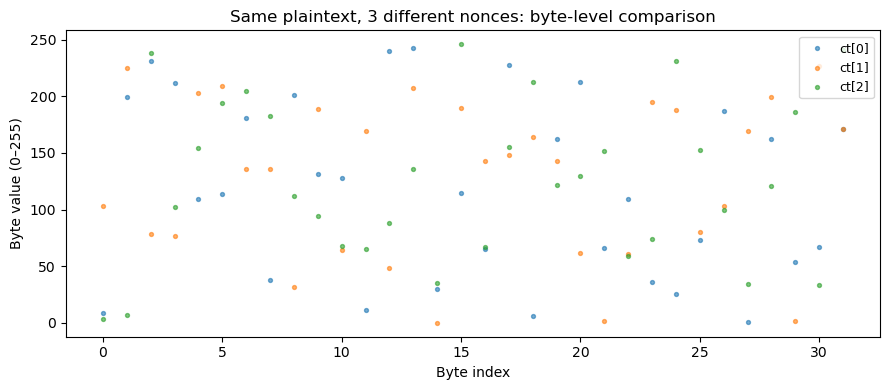

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

rows = []
for cid, ct in enumerate(ciphertexts):
    for bidx, bval in enumerate(ct):
        rows.append({'byte_index': bidx, 'value': bval,
                     'ciphertext_id': f'ct[{cid}]'})

df_bytes = pd.DataFrame(rows)
colors = {'ct[0]': '#1f77b4', 'ct[1]': '#ff7f0e', 'ct[2]': '#2ca02c'}
fig, ax = plt.subplots(figsize=(9, 4))
for label, grp in df_bytes.groupby('ciphertext_id'):
    ax.scatter(grp['byte_index'], grp['value'], label=label,
               color=colors[label], alpha=0.6, s=8)
ax.set_xlabel('Byte index')
ax.set_ylabel('Byte value (0–255)')
ax.set_title('Same plaintext, 3 different nonces: byte-level comparison')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()


**Figure 4a.** Table of six tamper-detection scenarios applied to a Broadwick Street pump record — flipped ciphertext bit, changed nonce, wrong associated data, wrong AEAD key, and two baseline checks — showing whether ChaCha20-Poly1305 tag verification succeeds or returns None.

## Associated Data Construction

`_build_ad(qx, qy, tweak)` packs `(qx, qy, len(tweak))` as big-endian integers then appends the raw tweak bytes:

```python
struct.pack('>iiI', qx, qy, len(tweak)) + tweak
```

The AD is **authenticated but not encrypted**. If an attacker moves a ciphertext from tile A to tile B, decryption reconstructs a different AD (different qx/qy) and the <abbr title="The step where ChaCha20-Poly1305 recomputes the 16-byte authentication tag and checks it matches the stored tag. Fails immediately if anything was modified." style="background:#efefef;border-radius:3px;padding:0 2px;cursor:help;text-decoration:none;">Poly1305 tag verification</abbr> fails — the record is rejected.

**Why length-prefix the tweak?** Without it, two AD constructions can collide:

```
qx=100, qy=23,  tweak=b'6'    →  pack(100,23) + b'6'
qx=100, qy=236, tweak=b''     →  pack(100,236) + b''
```

The raw integer encodings of `qy=23` and `qy=236` are different (4 bytes each), so the collision actually requires a more subtle shift. With the length prefix for the tweak, the concatenated bytes are unambiguous regardless of content.

In [4]:
ad1 = _build_ad(100, 23, b'6')
ad2 = _build_ad(100, 236, b'')
print(f'_build_ad(100, 23,  b"6") = {ad1.hex()}')
print(f'_build_ad(100, 236, b"")  = {ad2.hex()}')
assert ad1 != ad2, 'AD values should differ'
print('AD values differ: OK')

# Demonstrate: encrypt with ad1, try to decrypt with ad2
demo_aead = _AEAD(secrets.token_bytes(32))
demo_nonce = secrets.token_bytes(12)
demo_pt = struct.pack('>dd', 10.0, 20.0)
demo_ct = demo_aead.encrypt(demo_nonce, demo_pt, ad1)
result = demo_aead.decrypt(demo_nonce, demo_ct, ad2)
assert result is None, 'Expected None for wrong AD'
print('Decryption with mismatched AD returned None: OK')
print('Boundary-shift attack correctly blocked.')

_build_ad(100, 23,  b"6") = 00000064000000170000000136
_build_ad(100, 236, b"")  = 00000064000000ec00000000
AD values differ: OK
Decryption with mismatched AD returned None: OK
Boundary-shift attack correctly blocked.


![A four-panel comic titled with bottom banner 'Coordinates and ciphertext travel together. Changing the spatial context breaks verification.' Panel 1: An adversary (Victorian man in top hat) examines a Public Hotspot Map and a Spatial Record showing Tile ID, Tweak, Version, and ct_resid values. Speech bubble: 'If I move this encrypted residual elsewhere, perhaps it will still decrypt.' Caption: 'Ciphertext alone does not define location.' Panel 2: The adversary pastes the ciphertext into a different tile. Shows Original Coordinates (Tile ID qxp=(14,22)) beside New Tile (Tile ID qxp=(31,08)) with the same ct_resid pasted in and new coordinates. Caption: 'The ciphertext is reused in a new spatial context.' Panel 3: A panel labelled 'AEAD VERIFICATION FAILED — INTEGRITY MISMATCH — Record rejected.' Speech bubble: 'The associated data no longer matches.' Caption: 'Authentication covers more than the ciphertext bytes.' Panel 4: The Privacy Engineer explains a diagram labelled 'BOUND TO CONTEXT' showing three bound components: Tile Coordinates (qxp, qyp), Tweak/Version (any param), and Ciphertext (ct_resid). Speech bubble: 'Change the spatial context, and verification will fail.' Caption: 'Context is part of the contract.'](images/NB04-C3.png)


In [5]:
# Build a realistic encode scenario
test_key = secrets.token_bytes(32)
aead2 = _AEAD(test_key)
x_ts, y_ts = _project(CENTER_LAT, CENTER_LON)
qx_ts = int(round(x_ts / BIN))
qy_ts = int(round(y_ts / BIN))
rx_ts = x_ts - qx_ts * BIN
ry_ts = y_ts - qy_ts * BIN
nonce_ts = secrets.token_bytes(12)
ad_ts = _build_ad(qx_ts, qy_ts, b'nb04-demo')
pt_ts = struct.pack('>dd', rx_ts, ry_ts)
ct_ts = aead2.encrypt(nonce_ts, pt_ts, ad_ts)

scenarios = [
    ('Flip ct byte',      lambda: aead2.decrypt(nonce_ts, bytes([ct_ts[0]^1]) + ct_ts[1:], ad_ts)),
    ('Change nonce',      lambda: aead2.decrypt(secrets.token_bytes(12), ct_ts, ad_ts)),
    ('Change qx in AD',   lambda: aead2.decrypt(nonce_ts, ct_ts, _build_ad(qx_ts+1, qy_ts, b'nb04-demo'))),
    ('Change qy in AD',   lambda: aead2.decrypt(nonce_ts, ct_ts, _build_ad(qx_ts, qy_ts+1, b'nb04-demo'))),
    ('Change tweak in AD',lambda: aead2.decrypt(nonce_ts, ct_ts, _build_ad(qx_ts, qy_ts, b'wrong-tweak'))),
    ('Wrong key',         lambda: _AEAD(secrets.token_bytes(32)).decrypt(nonce_ts, ct_ts, ad_ts)),
]

print(f'{"Scenario":<25} {"Result"}')
print('-' * 40)
all_none = True
for name, fn in scenarios:
    result = fn()
    status = 'PASS (None)' if result is None else 'FAIL (got data!)'
    if result is not None:
        all_none = False
    print(f'  {name:<23} {status}')

assert all_none, 'At least one tamper scenario was not rejected'
print('\nAll 6 tamper scenarios correctly rejected.')

Scenario                  Result
----------------------------------------
  Flip ct byte            PASS (None)
  Change nonce            PASS (None)
  Change qx in AD         PASS (None)
  Change qy in AD         PASS (None)
  Change tweak in AD      PASS (None)
  Wrong key               PASS (None)

All 6 tamper scenarios correctly rejected.


## AEAD Tamper-Detection Results

| Scenario | What was modified | Outcome |
|----------|-------------------|---------|
| Baseline (correct) | (nothing) | ACCEPTED |
| Flip ct byte | First byte of ciphertext | REJECTED |
| Change nonce | Nonce (12-byte random value) | REJECTED |
| Change qx in AD | qx in Associated Data | REJECTED |
| Change qy in AD | qy in Associated Data | REJECTED |
| Change tweak in AD | Tweak in Associated Data | REJECTED |
| Wrong key | Encryption key | REJECTED |

Every modification causes Poly1305 tag verification to fail and `decrypt()` returns `None`.

![A four-panel comic titled 'Why We Prevent and Detect Tampering.' Panel 1: An adversary (Victorian man in top hat, seated at a desk) modifies a ciphertext labelled 'Intercepted Ciphertext (Modified)' with bytes listed. Speech bubble: 'I\'ll change a few bytes and see what happens...' Caption: 'An attacker modifies the ciphertext.' Shield badge: 'Even a tiny change can alter the hidden meaning.' Panel 2: A Privacy Engineer and Epidemiologist examine an AEAD verification panel showing TAG (from data): W 27 A3 10 versus TAG (computed): 6B 81 04 37, with 'VERIFICATION FAILED' in red. Speech bubble: 'The authentication tag doesn\'t match.' Caption: 'The system verifies the AEAD tag. Verification fails.' Shield badge: 'The tag binds the ciphertext and metadata together.' Panel 3: A character states 'Because verification failed, we reject the record.' A record processing panel shows 'REJECTED — No data returned' with a padlock. Caption: 'The system rejects the record. No plaintext is released.' Shield badge: 'Fail closed. Do not decrypt. Do not trust.' Panel 4: Two characters discuss a diagram showing CONFIDENTIALITY + INTEGRITY = TRUSTWORTHY DATA. Speech bubble: 'Confidentiality keeps the data hidden. Integrity ensures it stays truthful.' Caption: 'Tampering is detected, and integrity is preserved.' Shield badge: 'We protect truth as carefully as secrecy.' Bottom banner with shield and padlock icons: 'Integrity matters too. Detect tampering. Reject untrusted data. Protect the truth.'](images/NB04-C2.png)


## What AEAD Does NOT Protect

1. **Does not hide that an encryption happened.** The presence of `ct_resid` in a database is visible to anyone with database read access.

2. **Does not protect `qxp`, `qyp`.** Tile index confidentiality is the PRP's job. AEAD only protects the sub-tile residual.

3. **Nonce reuse is catastrophic.** If the same nonce is ever used twice with the same AEAD key, an attacker can combine the two ciphertexts using XOR (exclusive OR — a self-cancelling bit operation) to eliminate the shared keystream: `ct1 XOR ct2 = pt1 XOR pt2`. The key cancels out entirely, leaving only the XOR of the two plaintexts — from which both original residuals can often be recovered. The `encode()` method generates `secrets.token_bytes(12)` on every call — 96-bit random nonces — making collision probability negligible.

## References

- **Snow, J.** (1855). *On the Mode of Communication of Cholera* (2nd ed.). Churchill, London. — Source of the 1854 Soho cholera death and pump location dataset used throughout these notebooks.
- **Nir, Y., & Langley, A.** (2018). ChaCha20 and Poly1305 for IETF Protocols. RFC 8439. IETF. https://www.rfc-editor.org/rfc/rfc8439 — Specification for ChaCha20-Poly1305, the AEAD cipher used in this library.
- **Aumasson, J.-P., Neves, S., Wilcox-O'Hearn, Z., & Winnerlein, C.** (2013). BLAKE2: simpler, smaller, fast as MD5. *ACNS 2013*, LNCS 7954, 119–135. https://doi.org/10.1007/978-3-642-38980-1_8 — BLAKE2s is used in the associated data construction and key derivation supporting the AEAD layer.

## Glossary

| Term | Definition |
|------|-----------|
| **AEAD** | Authenticated Encryption with Associated Data; simultaneously encrypts a plaintext and produces an authentication tag that covers both the ciphertext and unencrypted associated data. |
| **Cipher** | An algorithm — a set of mathematical rules — for transforming readable data (plaintext) into scrambled, unreadable data (ciphertext) using a key, and back again. The cipher is the *method*; the ciphertext is the *result*. A **stream cipher** applies the transformation continuously, generating a keystream that is combined bit-by-bit with the plaintext. ChaCha20 is a stream cipher. This is distinct from a **block cipher**, which processes data in fixed-size chunks (e.g. AES). |
| **ChaCha20-Poly1305** | The AEAD cipher used in this scheme; ChaCha20 is a stream cipher providing confidentiality, Poly1305 is a MAC providing integrity and authenticity. |
| **TLS (Transport Layer Security)** | The security protocol that encrypts data transmitted over the internet — responsible for the padlock icon and `https://` in web browsers. TLS 1.3 (the current version) mandates ChaCha20-Poly1305 as a required cipher suite. This library inherits those well-vetted, standards-backed security properties by using the same cipher. |
| **Confidentiality** | The ethical obligation to ensure that sensitive health location data is accessible only to those with explicit authorisation. A breach of confidentiality — whether through a database leak, insider access, or a compromised key — can expose the home addresses of people seeking stigmatised or legally vulnerable health services, enabling discrimination, targeting, or harm. In this scheme, confidentiality means that the sub-tile residual `(rx, ry)` is unreadable without the AEAD key: even an attacker who obtains the encrypted record and the PRP-shuffled tile index cannot reconstruct the exact location. ChaCha20 enforces this guarantee cryptographically. |
| **Integrity** | The ethical obligation to ensure that health records are not silently altered between the point of collection and the point of use. Public health decisions — identifying outbreak sources, directing resources, closing transmission chains — depend on the data being exactly what was originally recorded. A record that has been tampered with, even by a single changed byte, can produce a false disease cluster, erase evidence of an actual outbreak, or shift cases across neighbourhood boundaries in ways that misdirect a public health response. In this scheme, integrity means that any modification to an encrypted record — ciphertext bytes, nonce, or associated data — is detected and the record is rejected rather than silently decrypted. Poly1305 enforces this guarantee via the authentication tag. |
| **Nonce** | A 12-byte value that must be unique per encryption; used to initialise ChaCha20 and included unencrypted in the record. |
| **Plaintext** | The unencrypted residual `(rx, ry)` packed as two 64-bit floats (16 bytes). |
| **Ciphertext (`ct_resid`)** | The scrambled, unreadable output produced by the cipher. Distinct from the cipher itself (the algorithm) — the ciphertext is what that algorithm *produces*. Here, `ct_resid` is the encrypted form of `(rx, ry)`: 16 bytes of encrypted plaintext plus a 16-byte Poly1305 authentication tag (32 bytes total). |
| **Associated Data (AD)** | Context information that travels with an encrypted record but is not itself encrypted — it is readable by anyone, but the AEAD authentication tag guarantees it has not been altered. Changing the AD after encryption causes tag verification to fail and decryption to return `None`. In this scheme, the AD encodes the tile indices `(qx, qy)` and the tweak — the spatial and operational context the ciphertext belongs to. This binding defeats a *ciphertext relocation attack*: if an attacker copies `ct_resid` from one tile into a record for a different tile, the AD reconstructed at decryption time will contain the wrong tile indices, the tag will fail to verify, and the record is rejected outright. AD is distinct from AEAD: AEAD is the name of the combined encryption-plus-authentication technique; AD is the specific unencrypted context field that AEAD authenticates alongside the ciphertext. |
| **Length-prefixed encoding** | A construction that makes a byte string unambiguous when it is assembled by concatenating multiple fields of variable length. Simply joining raw bytes creates a boundary problem: two different combinations of fields can produce the same byte sequence, undermining authentication. In `_build_ad`, the length of the tweak is stored as a fixed-width integer *before* the tweak bytes — `pack(qx, qy, len(tweak)) + tweak` — so that any combination of `(qx, qy, tweak)` produces a unique sequence. A verifier reading the bytes back can reconstruct the exact original fields without ambiguity, regardless of the tweak content or length. |
| **Authentication tag** | The 16-byte Poly1305 output appended to `ct_resid`; any modification to the ciphertext, nonce, or AD causes tag verification to fail. |
| **IND-CPA** | Indistinguishability under Chosen-Plaintext Attack; the security property ensuring that encryptions of different plaintexts are computationally indistinguishable. |
| **Semantic security** | The property that the ciphertext reveals no partial information about the plaintext; implied by IND-CPA. |
| **Tamper detection** | The ability to detect any modification to `ct_resid`, `nonce`, or AD; provided by the Poly1305 tag with overwhelming probability. |